# RAW DATASET


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
dataset_raw = pd.read_csv("https://raw.githubusercontent.com/micelll/SPARC-2026/main/SPARC_dataset.csv")
dataset_raw.head(10)

C:\Users\FLORENTINA REGITA\AppData\Local\Temp\ipykernel_27436\904082325.py:6: DtypeWarning: Columns (0: Kode POS, 1: wilayah, 2: tahun rakit, 3: DLR group, 4: tgl mohon) have mixed types. Specify dtype option on import or set low_memory=False.
  dataset_raw = pd.read_csv("https://raw.githubusercontent.com/micelll/SPARC-2026/main/SPARC_dataset.csv")


,Customer ID,Kelurahan,Kecamatan,Kode POS,Cash/Credit,Kode Dealer,Finance Company,Tenor,Gender,Tgl Lahir,...,range dp,wilayah,9 segment,kode motor,OTR,tahun rakit,DLR group,tgl cetak,tgl mohon,Kode Kota-Provinsi
0,CUST-159769,Baru Ilir,Balikpapan Barat,76131,2.0,12756.0,4,3,2,1992-03-03 0:00:00,...,2 - 3 juta,6471,AT LOW,HN,18685000.0,NaN,NaN,NaN,02-01-2019,6471-6400
1,CUST-164551,BARU TENGAH,BALIKPAPAN BARAT,76132,2.0,733.0,1,1,2,1991-04-27 0:00:00,...,3 jt up,6471,AT LOW,HN,18685000.0,NaN,NaN,NaN,02012019,6471-6400
2,CUST-159733,BARU TENGAH,BALIKPAPAN BARAT,76132,1.0,733.0,N,N,2,1982-01-04 0:00:00,...,kurang 1 juta,6471,AT MID,HR,20775000.0,NaN,NaN,NaN,02012019,6471-6400
3,CUST-164422,BARU TENGAH,BALIKPAPAN BARAT,76132,1.0,733.0,N,N,2,1997-06-26 0:00:00,...,krg 1 jt,6471,AT MID,HR,20775000.0,NaN,NaN,NaN,02012019,6471-6400
4,CUST-155472,Baru Ulu,Balikpapan Barat,76133,2.0,11160.0,1,2,1,1996-07-12 0:00:00,...,2 - 3 jt,6471,AT MID,HR,20775000.0,NaN,NaN,NaN,02-01-2019,6471-6400
5,CUST-218443,Klandasan Ilir,Balikpapan Kota,76113,2.0,10411.0,1,2,2,1996-04-26 0:00:00,...,3 jt up,6471,AT MID,HR,20775000.0,NaN,NaN,NaN,02-01-2019,6471-6400
6,CUST-199394,Klandasan Ilir,Balikpapan Kota,76113,1.0,12757.0,N,N,1,1982-08-09 0:00:00,...,krg 1 juta,6471,AT MID,HR,20775000.0,NaN,NaN,NaN,02012019,6471-6400
7,CUST-200209,KLANDASAN ULU,BALIKPAPAN KOTA,76112,1.0,733.0,N,N,1,1986-03-11 0:00:00,...,krg 1 juta,6471,AT LOW,HO,17975000.0,NaN,NaN,NaN,02012019,6471-6400
8,CUST-09898,TELAGA SARI,BALIKPAPAN KOTA,45261,1.0,733.0,N,N,1,1995-09-10 0:00:00,...,kurang 1 juta,6471,AT MID,HB,22495000.0,NaN,NaN,NaN,02012019,6471-6400
9,CUST-194316,DAMAI BAHAGIA,BALIKPAPAN SELATAN,76114,1.0,733.0,N,N,2,1984-11-25 0:00:00,...,krg 1 jt,6471,CUB LOW,GF,17460000.0,NaN,NaN,NaN,02-01-2019,6471-6400


# Exploration Data Analyst

## Missing Value Check and Cleaning Data

In [14]:
# cek informasi dataset untuk melihat tipe data dan nilai null
dataset_raw.info()

# mengganti nilai yang dianggap sebagai null dengan np.nan
dataset_raw.replace(["", " ", "N", "NA", "N/A", "NULL", "null", "-", "?", "nan-nan"], np.nan, inplace=True)

# mengisi nilai null dengan median untuk kolom numerik
numeric_col = dataset_raw.select_dtypes(include=["float64", "int64"]).columns
dataset_raw[numeric_col] = dataset_raw[numeric_col].fillna(dataset_raw[numeric_col].median())

category_col = dataset_raw.select_dtypes(include=["object", "string"]).columns
dataset_raw[category_col] = dataset_raw[category_col].fillna(dataset_raw[category_col].mode().iloc[0])
# cek nilai unik dan ubah tipe data untuk kolom yang sesuai
data_numeric = ["Tenor", "dp aktual", "cicilan", "tahun rakit", "Kode POS", "wilayah"]
for col in data_numeric:
    if col in dataset_raw.columns:
        dataset_raw[col] = pd.to_numeric(dataset_raw[col], errors="coerce")
        
data_date = ["Tgl Lahir", "tgl mohon"]
for col in data_date:
    if col in dataset_raw.columns:
        dataset_raw[col] = pd.to_datetime(dataset_raw[col], errors="coerce")

# drop kolom tidak relevan
drop_col = ["Customer ID", "Tgl Lahir", "tgl mohon", "Kode POS"]
dataset_raw.drop(columns=drop_col, inplace=True, errors="ignore")

# cek nilai null setelah penanganan
dataset_raw.isnull().sum()

# simpan dataset yang sudah dibersihkan
dataset_raw.to_csv("dataset_clean.csv", index=False)

#panggil dataset dan lakukan encoding untuk kolom kategorikal
dataset_new = pd.read_csv("dataset_clean.csv")
dataset_new.info()
dataset_new.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 319978 entries, 0 to 319977
Data columns (total 28 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Customer ID         319964 non-null  str    
 1   Kelurahan           319962 non-null  str    
 2   Kecamatan           319963 non-null  str    
 3   Kode POS            319963 non-null  object 
 4   Cash/Credit         319963 non-null  float64
 5   Kode Dealer         319963 non-null  float64
 6   Finance Company     319889 non-null  str    
 7   Tenor               319942 non-null  str    
 8   Gender              319962 non-null  str    
 9   Tgl Lahir           319963 non-null  str    
 10  Agama               319963 non-null  str    
 11  Pekerjaan           319963 non-null  str    
 12  umur                319963 non-null  float64
 13  dp aktual           319234 non-null  str    
 14  cicilan             319276 non-null  str    
 15  warna               319963 non-null  str    


,Kelurahan,Kecamatan,Cash/Credit,Kode Dealer,Finance Company,Tenor,Gender,Agama,Pekerjaan,umur,...,type series,range dp,wilayah,9 segment,kode motor,OTR,tahun rakit,DLR group,tgl cetak,Kode Kota-Provinsi
0,Baru Ilir,Balikpapan Barat,2.0,12756.0,4,3,2,1,2e,27.0,...,BREEZ SERIES,2 - 3 juta,6471.0,AT LOW,HN,18685000.0,2023.0,SX,12102019.0,6471-6400
1,BARU TENGAH,BALIKPAPAN BARAT,2.0,733.0,1,1,2,1,2b,28.0,...,BREEZ SERIES,3 jt up,6471.0,AT LOW,HN,18685000.0,2023.0,SX,12102019.0,6471-6400
2,BARU TENGAH,BALIKPAPAN BARAT,1.0,733.0,1,2,2,1,4b,37.0,...,SCOOTY SERIES,kurang 1 juta,6471.0,AT MID,HR,20775000.0,2023.0,SX,12102019.0,6471-6400
3,BARU TENGAH,BALIKPAPAN BARAT,1.0,733.0,1,2,2,1,11,22.0,...,SCOOTY SERIES,krg 1 jt,6471.0,AT MID,HR,20775000.0,2023.0,SX,12102019.0,6471-6400
4,Baru Ulu,Balikpapan Barat,2.0,11160.0,1,2,1,1,2e,23.0,...,SCOOTY SERIES,2 - 3 jt,6471.0,AT MID,HR,20775000.0,2023.0,SX,12102019.0,6471-6400
5,Klandasan Ilir,Balikpapan Kota,2.0,10411.0,1,2,2,1,2c,23.0,...,SCOOTY SERIES,3 jt up,6471.0,AT MID,HR,20775000.0,2023.0,SX,12102019.0,6471-6400
6,Klandasan Ilir,Balikpapan Kota,1.0,12757.0,1,2,1,1,2a,37.0,...,SCOOTY SERIES,krg 1 juta,6471.0,AT MID,HR,20775000.0,2023.0,SX,12102019.0,6471-6400
7,KLANDASAN ULU,BALIKPAPAN KOTA,1.0,733.0,1,2,1,1,2e,33.0,...,BREEZ SERIES,krg 1 juta,6471.0,AT LOW,HO,17975000.0,2023.0,SX,12102019.0,6471-6400
8,TELAGA SARI,BALIKPAPAN KOTA,1.0,733.0,1,2,1,1,7,24.0,...,VAREX 125 SERIES,kurang 1 juta,6471.0,AT MID,HB,22495000.0,2023.0,SX,12102019.0,6471-6400
9,DAMAI BAHAGIA,BALIKPAPAN SELATAN,1.0,733.0,1,2,2,1,6,35.0,...,RYVO SERIES,krg 1 jt,6471.0,CUB LOW,GF,17460000.0,2023.0,SX,12102019.0,6471-6400


## Data Distribution

In [15]:
# cek statistik deskriptif
display(dataset_new[["dp aktual", "cicilan", "OTR"]].describe())

# presentase pembayaran cash/credit
display(dataset_new["Cash/Credit"].value_counts(normalize=True) * 100)
display(dataset_new["Tenor"].value_counts(normalize=True) * 100)
display(dataset_new["wilayah"].value_counts(normalize=True) * 100)


,dp aktual,cicilan,OTR
count,2.242060e+05,2.241950e+05,3.199780e+05
mean,1.583197e+07,8.417265e+06,6.540832e+07
std,6.918708e+07,3.687568e+08,9.052885e+07
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,2.117000e+07
50%,2.072500e+06,1.418000e+06,2.361500e+07
75%,2.395000e+07,1.270000e+07,3.404000e+07
max,3.000000e+10,8.575233e+10,9.301000e+08


Cash/Credit
2.0    56.416691
1.0    43.583309
Name: proportion, dtype: float64

Tenor
2    77.770034
1    12.069580
3    10.111945
4     0.046566
5     0.000938
6     0.000938
Name: proportion, dtype: float64

wilayah
6471.0    36.522745
6401.0    15.105402
6405.0    15.057897
6571.0    10.007970
6409.0     9.440095
            ...    
1279.0     0.000313
6105.0     0.000313
6311.0     0.000313
7476.0     0.000313
6308.0     0.000313
Name: proportion, Length: 217, dtype: float64

## Visualisasi Distribusi Data

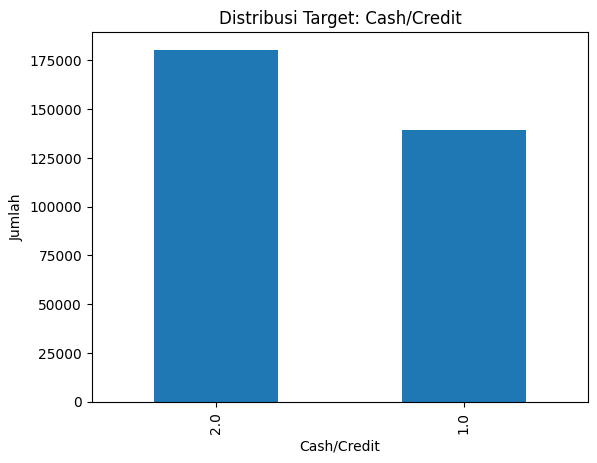

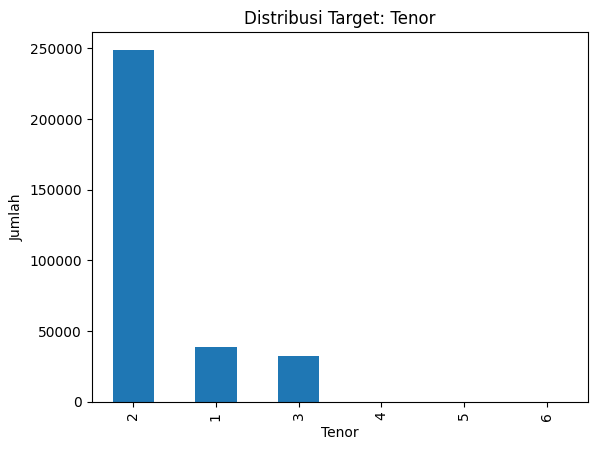

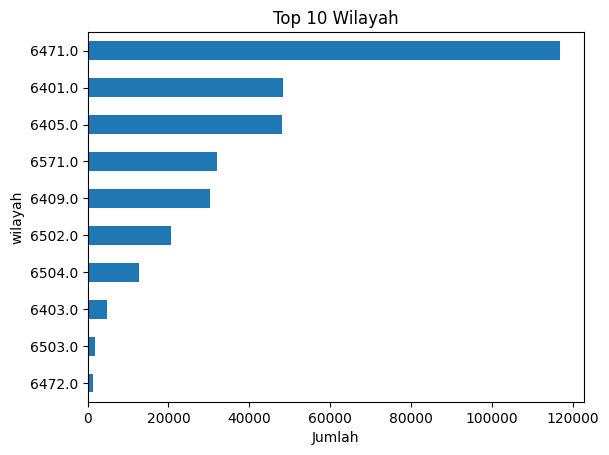

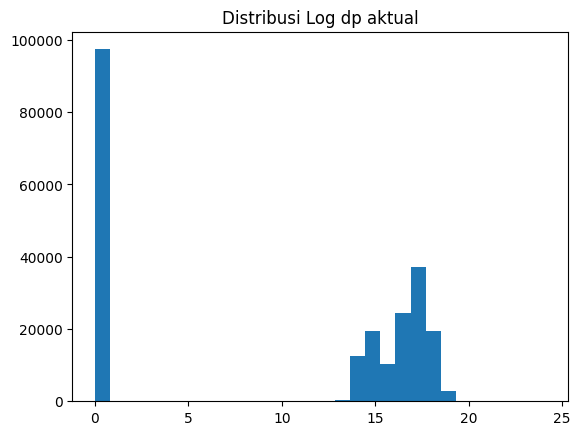

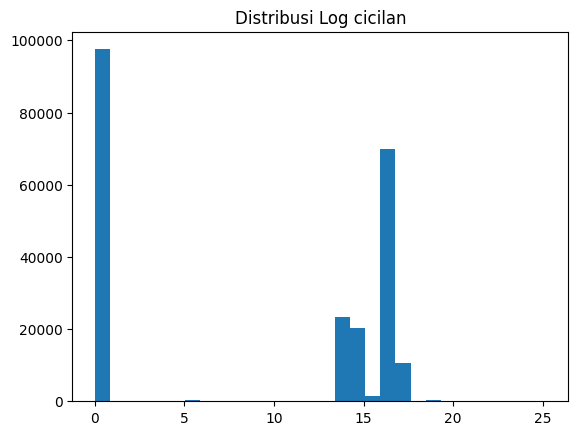

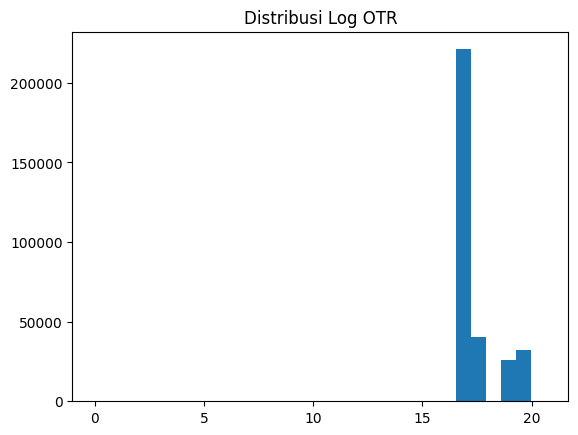

In [16]:
# visualisasi distribusi data
dataset_new["Cash/Credit"].value_counts().plot(kind="bar")
plt.title("Distribusi Target: Cash/Credit")
plt.ylabel("Jumlah")
plt.show()

dataset_new["Tenor"].value_counts().plot(kind="bar")
plt.title("Distribusi Target: Tenor")
plt.ylabel("Jumlah")
plt.show()

dataset_new["wilayah"].value_counts().head(10).plot(kind="barh")
plt.title("Top 10 Wilayah")
plt.xlabel("Jumlah")
plt.gca().invert_yaxis()
plt.show()

statistic_numeric = ["dp aktual", "cicilan", "OTR"]
for col in statistic_numeric:
    plt.figure()
    plt.hist(np.log1p(dataset_new[col]), bins=30)
    plt.title(f"Distribusi Log {col}")
    plt.show()




# Split Data

## cash credit

In [17]:
from sklearn.model_selection import train_test_split
X = dataset_new.drop("Cash/Credit", axis=1)
y = dataset_new["Cash/Credit"]
X_train_cc, X_test_cc, y_train_cc, y_test_cc = train_test_split( X, y, test_size=0.2, stratify=y, random_state=1 )
print("Train shape:", X_train_cc.shape)
print("Test shape:", X_test_cc.shape)

Train shape: (255982, 23)
Test shape: (63996, 23)


## Dp aktual

In [20]:
dataset_dp = dataset_new.dropna(subset=["dp aktual"])
X_dp = dataset_dp.drop("dp aktual", axis=1)
y_dp = dataset_dp["dp aktual"]
X_train_dp, X_test_dp, y_train_dp, y_test_dp = train_test_split(X_dp, y_dp,test_size=0.2,random_state=1)
print("Train shape:", X_train_dp.shape)
print("Test shape:", X_test_dp.shape)

Train shape: (179364, 23)
Test shape: (44842, 23)


# Model

## Cash credit

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=1
)

model.fit(X_train_cc, y_train_cc)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Dp aktual

In [ ]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

reg = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

reg.fit(X_dp, y_dp)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

## Cluster

In [21]:
from sklearn.preprocessing import StandardScaler
numeric_cols = dataset_new.select_dtypes(include=["float64", "int64"]).columns
X_cluster = dataset_new[numeric_cols]
X_cluster = X_cluster.dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
dataset_new.loc[X_cluster.index, "Cluster"] = clusters
dataset_new["Cluster"].value_counts()


Cluster
0.0    69284
1.0    68334
3.0    27908
2.0    18758
Name: count, dtype: int64

# Feature Important

## Random Forest

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feature_importance.head(10))

                  Feature  Importance
7                 cicilan    0.208523
6               dp aktual    0.203255
3575    range dp_krg 1 jt    0.131082
3576  range dp_krg 1 juta    0.073371
3573     range dp_3 jt up    0.059027
1         Finance Company    0.033298
3571    range dp_2 - 3 jt    0.031261
2                   Tenor    0.030182
3574   range dp_3 juta up    0.030087
3572  range dp_2 - 3 juta    0.014950


## Regression

In [ ]:
importance = pd.DataFrame({
    "Feature": X_dp.columns,
    "Importance": reg.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance.head(10))

                 Feature  Importance
7                cicilan    0.252977
9                    OTR    0.144299
2        Finance Company    0.079341
3659       kode motor_LJ    0.077227
3471        Pekerjaan_4e    0.053298
3574  range dp_3 juta up    0.049420
3573    range dp_3 jt up    0.047177
3701        DLR group_SX    0.037433
10           tahun rakit    0.036438
1            Kode Dealer    0.024785


# Evaluation Model

## Cash Credit

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
y_pred_cc = model.predict(X_test_cc)
print("Accuracy:", accuracy_score(y_test_cc, y_pred_cc))
print(confusion_matrix(y_test_cc, y_pred_cc))
print(classification_report(y_test_cc, y_pred_cc))

Accuracy: 0.9970935683480218
[[27799    93]
 [   93 36011]]
              precision    recall  f1-score   support

         1.0       1.00      1.00      1.00     27892
         2.0       1.00      1.00      1.00     36104

    accuracy                           1.00     63996
   macro avg       1.00      1.00      1.00     63996
weighted avg       1.00      1.00      1.00     63996



## Dp Aktual

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
y_pred_dp = reg.predict(X_test_dp)

mae = mean_absolute_error(y_test_dp, y_pred_dp)
mse = mean_squared_error(y_test_dp, y_pred_dp)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_dp, y_pred_dp)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 1271825.9216402033
RMSE: 5442108.845465992
R2 Score: 0.964395052718004


## Cluster

In [ ]:
cluster_profile = dataset_new.groupby("Cluster")[numeric_cols].mean()
print(cluster_profile)

         Cash/Credit    Kode Dealer  Finance Company     Tenor    Gender  \
Cluster                                                                    
0.0         1.999988   11452.900600         2.306193  2.013158  1.425655   
1.0         1.577463  113383.872237         1.849636  1.932554  1.454050   
2.0         1.000000   10671.054935         1.000000  2.000805  1.439833   
3.0         1.171613   11171.601938         1.072176  1.895014  1.459742   

            Agama        umur     dp aktual       cicilan      wilayah  \
Cluster                                                                  
0.0      1.103464   35.238127  2.925532e+07  1.405943e+07  6457.160086   
1.0      1.136211  360.228148  2.297681e+07  1.409220e+07  6454.107372   
2.0      1.067562   36.517482  8.366853e+05  4.452391e+05  6459.492781   
3.0      1.540833   37.414996  1.603898e+06  6.531616e+05  6429.034823   

                  OTR  tahun rakit     tgl cetak  Cluster  
Cluster                               